# WSA_02 — RF Demand Forecast Sensitivity

**Purpose.** Run the frozen horizon-specific RF and XGBoost models once, then quantify RF demand sensitivity against Baseline.

> Run from the project repository. Outputs are generated only from the project data and frozen model artifacts.

In [1]:
# Import libraries
from pathlib import Path
import sys, json, pandas as pd, numpy as np, matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG = PROJECT_ROOT / "configs" / "weather_sensitivity.yaml"
CONFIG

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/weather_sensitivity.yaml')

In [3]:
# Import modules for weather_sensitivity
from src.ontario_peak_risk.weather_sensitivity.common import load_config, ensure_dirs

In [4]:
cfg, project_root = load_config(CONFIG)
paths = ensure_dirs(cfg, project_root)
print("Project root:", project_root)

Project root: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk


In [5]:
from src.ontario_peak_risk.inference_feature_builder.run_ifb import run_ifb
from src.ontario_peak_risk.weather_sensitivity.scenarios import build_scenario_frames
from src.ontario_peak_risk.weather_sensitivity.validation import temperature_reference, add_domain_status
from src.ontario_peak_risk.weather_sensitivity.inference import run_sensitivity
from src.ontario_peak_risk.weather_sensitivity.comparison import add_baseline_deltas

In [6]:
# Rebuild IFB/scenario frames so this notebook is independently reproducible.
# This uses the same corrected temperature-reference logic as WSA_01.
import yaml

origin = pd.Timestamp(cfg['analysis']['forecast_origin'])
fsas = list(cfg['analysis']['fsas'])
temp = cfg['analysis']['temperature_feature']

# 1) Build frozen operational feature frames without executing the models.
ifb = run_ifb(
    project_root / cfg['paths']['ifb_config'],
    forecast_origin=origin,
    fsas=fsas,
    execute_models=False,
)
frames = ifb['feature_frames']

# 2) Read the historical/source temperature column from the IFB config.
# Historical feature data contains Temp (°C), while the frozen model frames
# expose the operational feature as origin__Temp (°C).
ifb_config_path = project_root / cfg['paths']['ifb_config']
with ifb_config_path.open('r', encoding='utf-8') as handle:
    ifb_cfg = yaml.safe_load(handle)

source_temp = ifb_cfg['columns']['temperature']
feature_dataset_path = project_root / cfg['paths']['feature_dataset']
feature_data = pd.read_parquet(feature_dataset_path)

if source_temp not in feature_data.columns:
    raise KeyError(
        f"Historical temperature column '{source_temp}' was not found in "
        f"{feature_dataset_path}."
    )

# 3) Build model-development temperature support from the historical source field.
q = tuple(cfg['analysis']['caution_quantiles'])
ref = temperature_reference(feature_data, feature=source_temp, q=q)

# 4) Validate the frozen operational temperature feature in all RF/XGB frames.
missing_temp_frames = []
for task in ['rf', 'xgb']:
    for h in range(1, int(cfg['analysis']['horizons']) + 1):
        if temp not in frames[task][h].columns:
            missing_temp_frames.append(f'{task}:h{h:02d}')

if missing_temp_frames:
    raise KeyError(
        f"Frozen temperature feature '{temp}' is missing from: "
        + ', '.join(missing_temp_frames)
    )

# 5) Construct the five controlled temperature scenarios and add domain status.
sc = build_scenario_frames(
    frames,
    cfg['analysis']['scenarios_c'],
    temp,
)

for task in ['rf', 'xgb']:
    for h in range(1, int(cfg['analysis']['horizons']) + 1):
        sc[task][h] = add_domain_status(sc[task][h], ref, temp)

# 6) Load frozen model metadata only (model artifacts are loaded sequentially later).
metadata = {}
for task in ['rf', 'xgb']:
    metadata_path = (
        project_root
        / cfg['paths']['artifacts_dir']
        / cfg['models'][f'{task}_subdir']
        / 'metadata.json'
    )
    if not metadata_path.exists():
        raise FileNotFoundError(f'Model metadata not found: {metadata_path}')
    metadata[task] = json.loads(metadata_path.read_text(encoding='utf-8'))

print('Historical temperature feature:', source_temp)
print('Operational temperature feature:', temp)
print('Temperature support:', ref)
print('Scenario rows per task:', sum(len(sc['rf'][h]) for h in sc['rf']))
print('Scenario construction and validation: PASS')
print('Starting sequential model inference (one RF + one XGB horizon at a time)...')


e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\inference_feature_builder\io.py:198: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  combined[col] = combined[update].combine_first(combined.get(col))


Historical temperature feature: Temp (°C)
Operational temperature feature: origin__Temp (°C)
Temperature support: {'min': -21.8, 'q_low': -11.9, 'q_high': 29.4, 'max': 35.8, 'n': 262803}
Scenario rows per task: 720
Scenario construction and validation: PASS
Starting sequential model inference (one RF + one XGB horizon at a time)...


In [7]:
# Execute frozen models sequentially and create the shared sensitivity master table.
# The underlying inference module loads one RF + one XGB horizon at a time,
# evaluates all five scenarios, then releases the models to control memory usage.
raw = run_sensitivity(sc, metadata, cfg, project_root)

expected_rows = (
    len(fsas)
    * int(cfg['analysis']['horizons'])
    * len(cfg['analysis']['scenarios_c'])
)
if len(raw) != expected_rows:
    raise ValueError(
        f'Unexpected inference row count: {len(raw)}; expected {expected_rows}.'
    )

results = add_baseline_deltas(raw)

required_result_cols = [
    'forecast_consumption_kwh',
    'baseline_forecast_kwh',
    'forecast_delta_kwh',
    'forecast_delta_pct',
    'peak_risk_score',
    'baseline_peak_risk_score',
    'peak_risk_delta',
    'peak_alert',
    'baseline_peak_alert',
    'alert_changed',
]
missing_cols = [c for c in required_result_cols if c not in results.columns]
if missing_cols:
    raise KeyError(f'Missing expected sensitivity result columns: {missing_cols}')

results.to_csv(
    paths['outputs_dir'] / 'WSA_sensitivity_master.csv',
    index=False,
)
results.to_parquet(
    paths['outputs_dir'] / 'WSA_sensitivity_master.parquet',
    index=False,
)

print('Rows:', len(results))
print('Expected rows:', expected_rows)
print('Master sensitivity output: PASS')


Rows: 720
Expected rows: 720
Master sensitivity output: PASS


In [8]:
# Extract and persist the Random Forest demand-sensitivity results.
rf_columns = [
    'fsa',
    'forecast_origin',
    'target_timestamp',
    'horizon',
    'scenario',
    'temperature_delta_c',
    'baseline_temperature_c',
    temp,
    'temperature_domain_status',
    'forecast_consumption_kwh',
    'baseline_forecast_kwh',
    'forecast_delta_kwh',
    'forecast_delta_pct',
]

missing_rf_cols = [c for c in rf_columns if c not in results.columns]
if missing_rf_cols:
    raise KeyError(f'Missing RF sensitivity columns: {missing_rf_cols}')

rf = results[rf_columns].copy()
rf.to_csv(
    paths['outputs_dir'] / 'WSA_02_rf_forecast_sensitivity.csv',
    index=False,
)

scenario_summary = (
    rf.groupby('scenario', observed=True)[
        ['forecast_delta_kwh', 'forecast_delta_pct']
    ]
    .agg(['mean', 'min', 'max'])
)
display(scenario_summary)
print('RF sensitivity rows:', len(rf))


forecast_delta_kwh                         forecast_delta_pct  \
                       mean         min         max               mean   
scenario                                                                 
+2.5C            -41.121149 -205.984713   80.628555          -0.425690   
+5C              -70.896180 -293.257204   90.688662          -0.765495   
-2.5C             84.056339  -91.278999  536.642827           0.852019   
-5C              221.786435  -90.702001  774.130697           2.317343   
Baseline           0.000000    0.000000    0.000000           0.000000   

                              
               min       max  
scenario                      
+2.5C    -2.436470  0.832941  
+5C      -3.468765  1.131453  
-2.5C    -0.898760  4.474730  
-5C      -0.893079  8.107088  
Baseline  0.000000  0.000000

RF sensitivity rows: 720


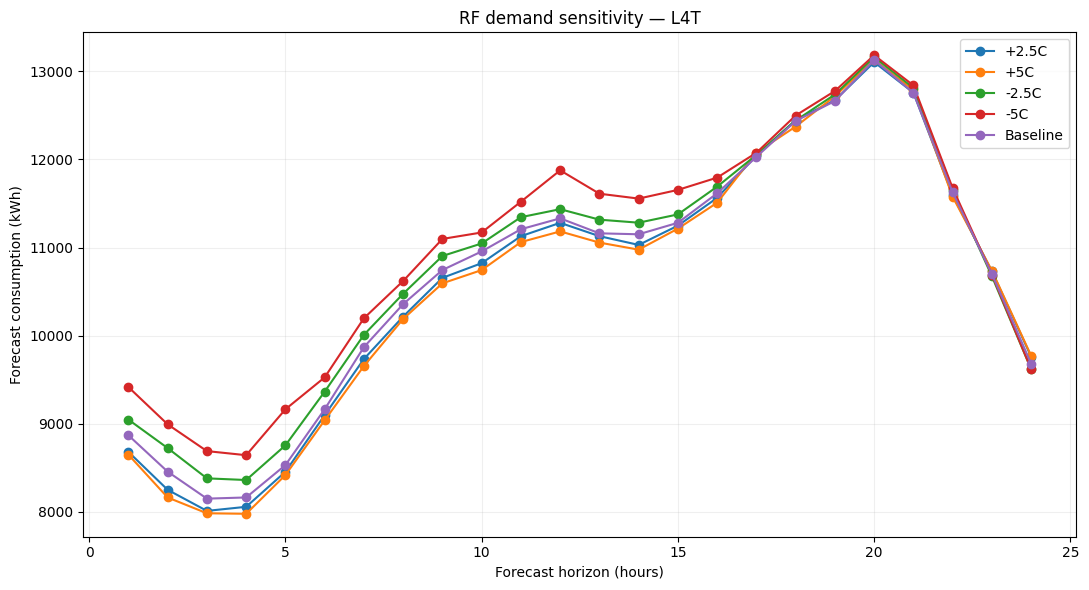

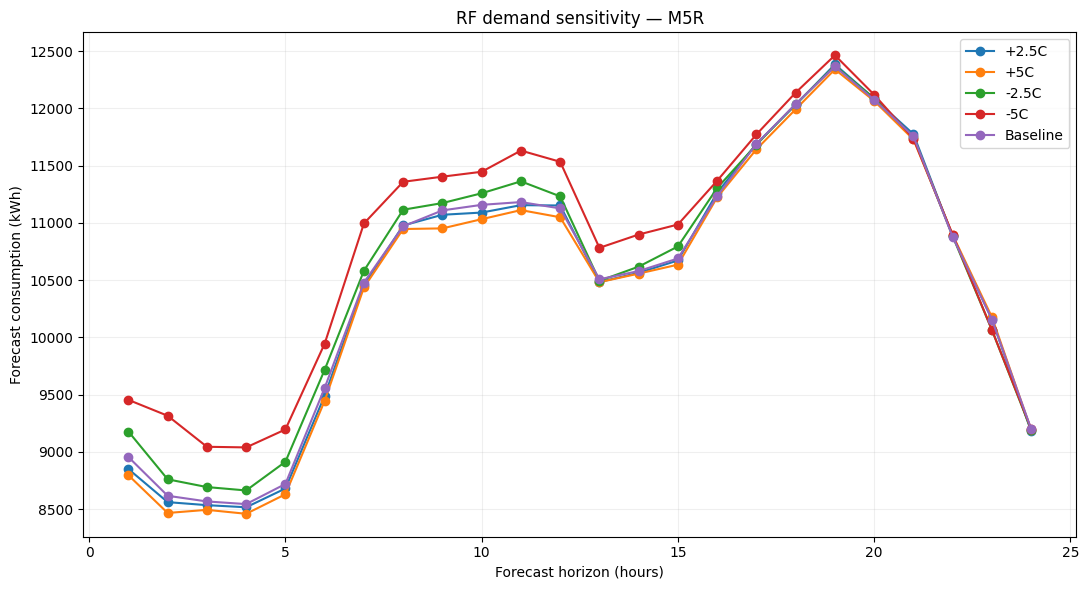

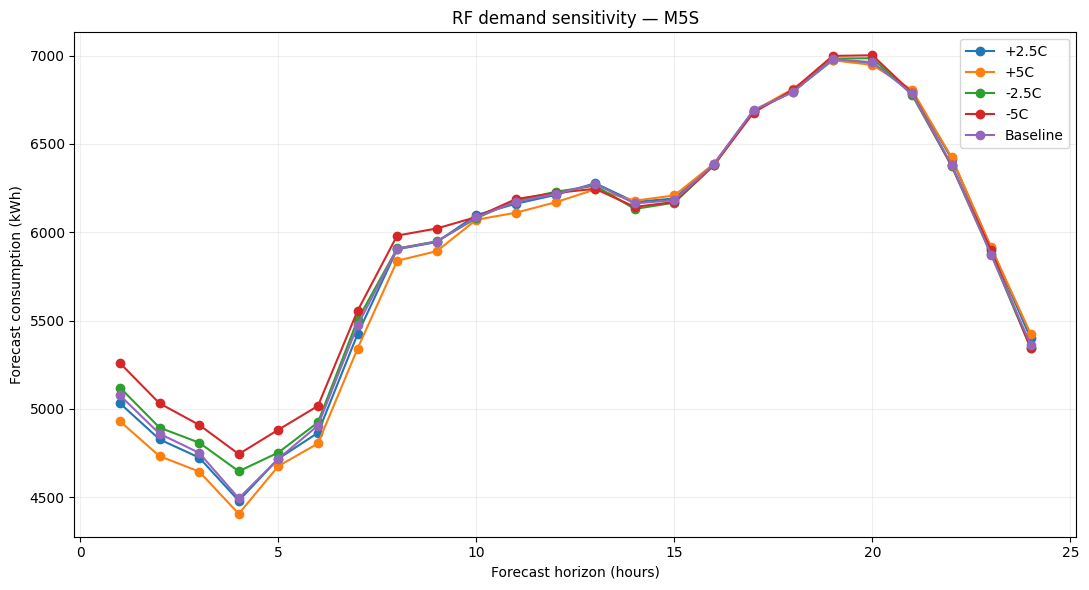

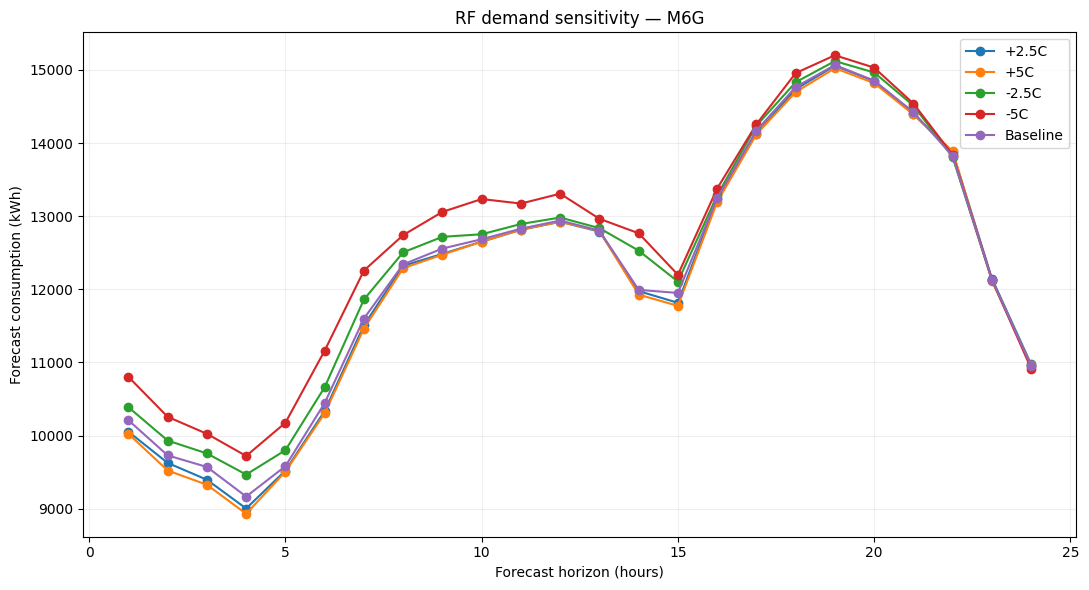

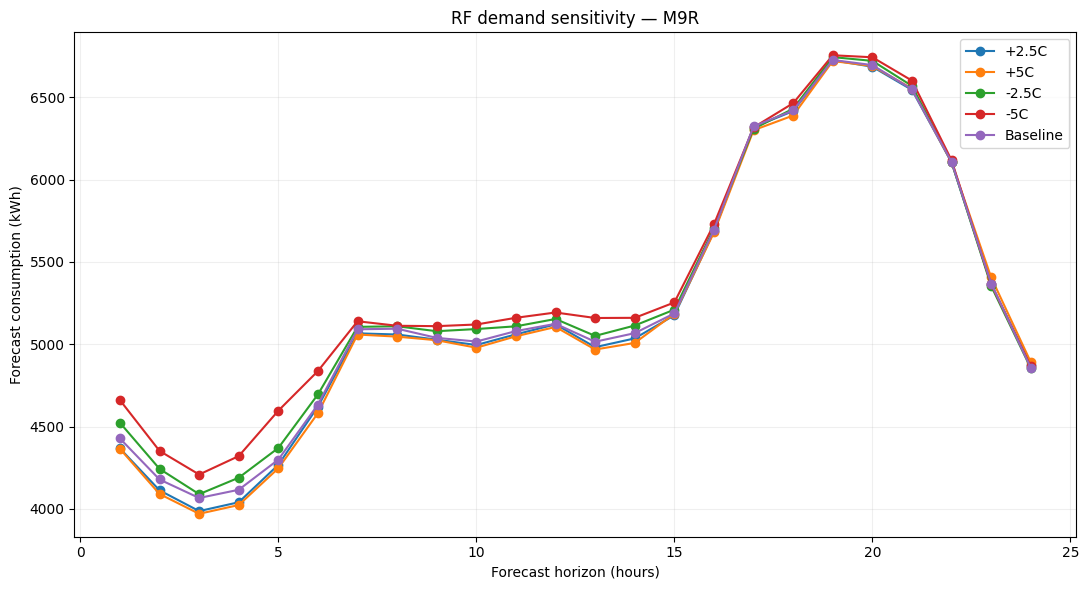

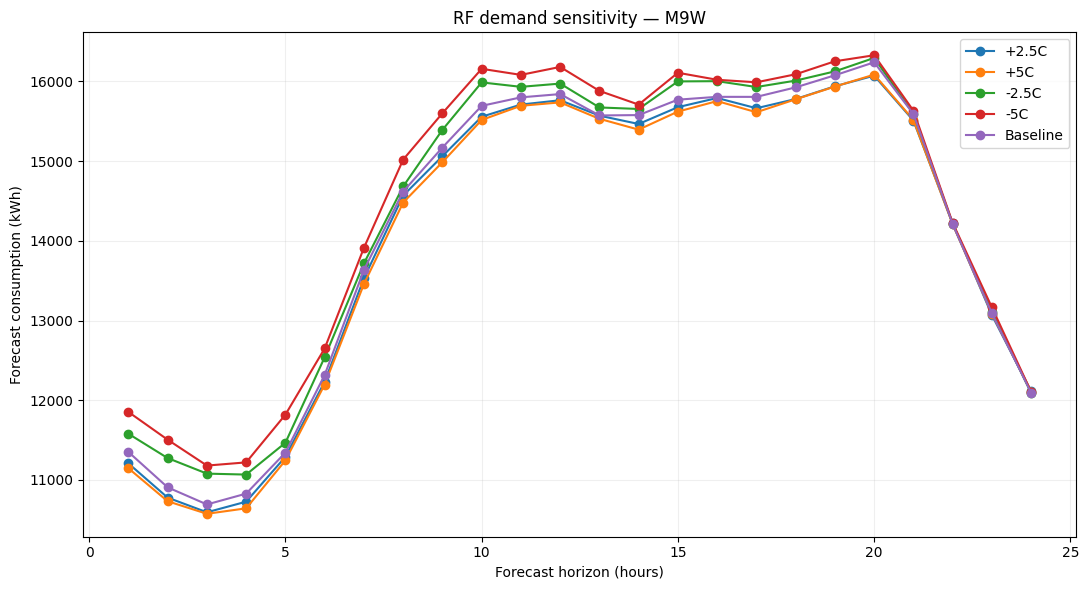

WSA_02 RESULT: COMPLETE


In [9]:
from src.ontario_peak_risk.weather_sensitivity.plotting import scenario_lines

for fsa in fsas:
    fsa_rf = rf.loc[rf['fsa'].eq(fsa)].sort_values(
        ['scenario', 'horizon']
    )
    if fsa_rf.empty:
        raise ValueError(f'No RF sensitivity rows found for FSA {fsa}.')

    fig = scenario_lines(
        fsa_rf,
        'forecast_consumption_kwh',
        f'RF demand sensitivity — {fsa}',
        'Forecast consumption (kWh)',
    )
    fig.savefig(
        paths['figures_dir'] / f'WSA_02_RF_{fsa}_forecast_scenarios.png',
        dpi=150,
        bbox_inches='tight',
    )
    plt.show()
    plt.close(fig)

print('WSA_02 RESULT: COMPLETE')
